# Nonlinear overlap h3 on a polar grid in a step-index fibre

> We compute and visualise the complex scalar quantity $h_3 = (\mathbf{E}_1\times\mathbf{E}_2)\cdot\mathbf{E}_3^*$ for a step-index fibre on a polar grid $(\rho,\phi)$.

This notebook shows how to:
- Define materials and a step-index fibre.
- Construct a polar sampling grid with approximately square cells at the edge.
- Evaluate guided modes and build $h_3$ for two circular polarisations ($S_3=+1$ and $S_3=-1$).
- Plot a polar HSV map of $\varepsilon_\mathrm{r}h_3$ (which is continuous) with colour = phase and brightness = magnitude, with a phase ring legend sharing the axis labels with angles.
- Integrate $h_3$ over the cladding (masked core) to obtain an area integral (reported symbolically with units).

> Tip: Heavy polar pcolormeshes are rasterised automatically in the plotting helper so that PDF export stays fast and small.

## Imports and utilities
We import Anafibre, Astropy units, NumPy, and Matplotlib. We'll also enable LaTeX labels via the plotting helper when available.

In [1]:
import numpy as np
import anafibre as af
from anafibre.plotting import plot_complex_field_polar
from anafibre.utils import pretty_length
import astropy.units as u
import matplotlib.pyplot as plt
from IPython.display import display, Latex

## Materials
We use fused silica (Malitson) for the core and water (Hale) for the cladding, pulling refractive indices from [refractiveindex.info](https://refractiveindex.info/).

In [2]:
SiO2  = af.RefractiveIndexMaterial(shelf='glass', book='fused_silica', page='Malitson')
H2O   = af.RefractiveIndexMaterial(shelf='main', book='H2O', page='Hale')

## Fibre geometry
We define a step-index fibre with a 250 nm core radius. The core radius sets a natural scale for the grid and for annotating radial ticks in the polar plots.

In [3]:
fibre = af.StepIndexFibre(
    core_radius = 250*u.nm, 
    core = SiO2,
    clad = H2O
) 

## Wavelengths and modes
We instantiate two HE11 modes at $\lambda_1$ and $\lambda_2$, and an HE21 mode at
$\lambda_3$ satisfying $\tfrac{1}{\lambda_3}=\tfrac{1}{\lambda_1}+\tfrac{1}{\lambda_2}$.
We also estimate the coherence length $L_c$ for phase-matching context and display the modes.

In [4]:
wl1 = 1000 * u.nm 
wl2 = 505.25 * u.nm 
wl3=1/(1/wl1+1/wl2)

HE11_wl1_R = fibre.HE(ell=1, n=1, wl=wl1, a_plus=1, a_minus=0)
HE11_wl2_L = fibre.HE(ell=1, n=1, wl=wl2, a_plus=0, a_minus=1)
TE01_wl3= fibre.TE(n=1, wl=wl3)
TM01_wl3 = fibre.TM(n=1, wl=wl3)
af.display_modes(HE11_wl1_R, HE11_wl2_L, TE01_wl3, TM01_wl3)

Lc_val = (np.pi / (HE11_wl1_R.kz + HE11_wl2_L.kz - TE01_wl3.kz))*u.m
display(Latex(f"$L_c = {pretty_length(Lc_val)}$ (TE)"))
Lc_val = (np.pi / (HE11_wl1_R.kz + HE11_wl2_L.kz - TM01_wl3.kz))*u.m
display(Latex(f"$L_c = {pretty_length(Lc_val)}$ (TM)"))


Mode,λ [nm],V,ne,s1,s2,s3
HE11,IR1000.00,0.92,1.3289,0.00,0.00,1.00
HE11,505.25,1.85,1.3792,0.00,0.00,-1.00
TE01,UV335.66,2.89,1.3623,-1.00,0.00,0.00
TM01,UV335.66,2.89,1.3647,1.00,0.00,0.00


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Polar sampling grid
We build a polar grid $(\rho,\phi)$ out to $r=5a$ with:
- Nr radial samples, linearly spaced in $\rho$.
- Nphi chosen so that $\Delta\phi\,r_{\max} \approx \Delta\rho$ giving roughly square cells at the edge, improving pcolormesh quality.
The meshgrid is created with `np.meshgrid(rho, phi)` so arrays are shaped (Nphi, Nr) as expected by our plotting helper.

In [5]:
r = 3 * fibre.core_radius  # Radius in micrometers
Nr = 300  # Number of points in radial direction
rho = np.linspace(0, r, Nr) * u.m
Nphi = int(2 * np.pi * (Nr-1))
phi = np.linspace(0, 2 * np.pi, Nphi)
Rho, Phi = np.meshgrid(rho, phi)

### Exporting figures
Saving to PDF can be slow if figures contain many vector polygons. The plotting helper rasterises the heavy meshes for you, so `fig.savefig(..., dpi=300)` should be quick while keeping text as vectors. Increase `dpi` if you need finer print resolution.

## Build and visualise $h_3$
- We normalise each mode so that power on the grid is 1.
- Compute $h_3 = (\mathbf{E}_1\times\mathbf{E}_2)\cdot\mathbf{D}_3^*$ and optionally mask the core so the cladding integral is emphasised.
- Plot with `plot_complex_field_polar` using:
  - colour = phase (cyclic HSV)
  - brightness = magnitude, percentile-scaled
  - a smooth phase ring around the axis (`phase_cbar_style='edge'`)
- Radial ticks are placed at integer multiples of the core radius. Radial tick labels are hidden for a clean dark background.

In [6]:
# Electric fields
E0 = HE11_wl1_R.E(rho=Rho, phi=Phi, z=0)
E1 = HE11_wl2_L.E(rho=Rho, phi=Phi, z=0)
E2 = TE01_wl3.E(rho=Rho, phi=Phi, z=0)
E3 = TM01_wl3.E(rho=Rho, phi=Phi, z=0)
# Plotting parameters
kwargsP = dict(
    variant="dark", Rho=Rho, Phi=Phi,
    title=r"$\varepsilon_\mathrm{r} h_3=(\mathbf{E}_1\times\mathbf{E}_2)\cdot\mathbf{D}_3^*$",
    mag_label=r"$|\varepsilon_\mathrm{r} h_3|$",
    core_radius=fibre.core_radius*u.m,
    phase_cbar_style="edge",
    cbar_pad=-0.06,
    use_tex=False,   # set True if your system has LaTeX installed
    # vmax=6e22
)

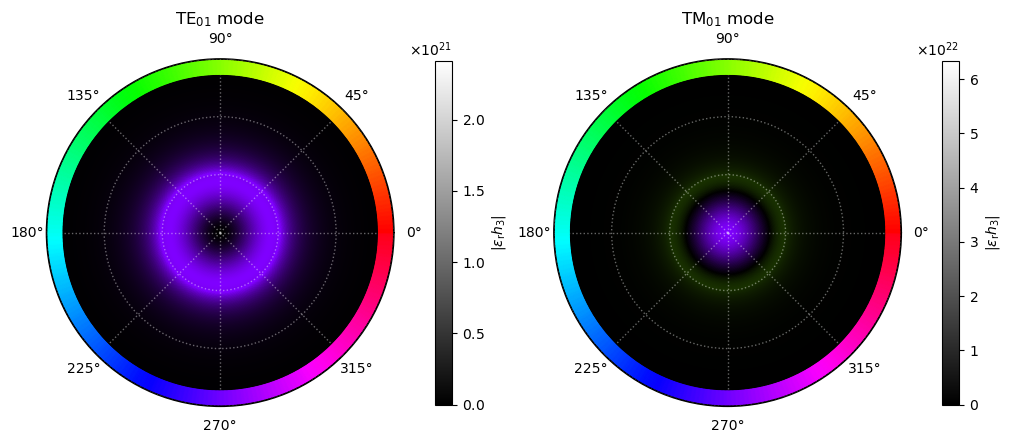

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
# Reuse existing fields and grid; compute both overlaps once
cross01 = np.cross(E0, E1)
h3_TE = np.sum(np.conjugate(E2) * cross01, axis=-1)
h3_TM = np.sum(np.conjugate(E3) * cross01, axis=-1)

h3_TE_masked = np.ma.masked_where(Rho.value < fibre.core_radius, h3_TE)
h3_TM_masked = np.ma.masked_where(Rho.value < fibre.core_radius, h3_TM)
h3_TE_eps = h3_TE * fibre.eps(Rho, wl3)
h3_TM_eps = h3_TM * fibre.eps(Rho, wl3)
h3_TE_masked_value = np.asarray(h3_TE_masked.filled(0.0 + 0.0j), dtype=np.complex128)
h3_TM_masked_value = np.asarray(h3_TM_masked.filled(0.0 + 0.0j), dtype=np.complex128)

# Area element (reuse if available)
dphi = 2*np.pi/Nphi
dr = rho.max()/(Nr-1)
dS = Rho * dr * dphi

H3_TE_ = np.sum(h3_TE_masked_value * (u.V/u.m)**3 * dS)
H3_TM_ = np.sum(h3_TM_masked_value * (u.V/u.m)**3 * dS)

# Side-by-side plots
fig, axs = plt.subplots(1, 2, subplot_kw=dict(projection='polar'), figsize=(10, 5), constrained_layout=True)

kwargsTE = {**kwargsP, 'title': r"$\mathrm{TE}_{01}$ mode"}
kwargsTM = {**kwargsP, 'title': r"$\mathrm{TM}_{01}$ mode"}

plot_complex_field_polar(h3_TE_eps, ax=axs[0], **kwargsTE)
plot_complex_field_polar(h3_TM_eps, ax=axs[1], **kwargsTM)
plt.show()

display(Latex(r"$\iiint\limits_\text{clad}h^\mathrm{TE}_{3}\,\mathrm{d}V"
              r" = " + H3_TE_._repr_latex_()[1:-1] + r" L_\mathrm{eff}$"))
display(Latex(r"$\iiint\limits_\text{clad}h^\mathrm{TM}_{3}\,\mathrm{d}V"
              r" = " + H3_TM_._repr_latex_()[1:-1] + r" L_\mathrm{eff}$"))


In [8]:
wl1 = 1000 * u.nm 
wl2 = 505.25 * u.nm 
wl3=1/(1/wl1+1/wl2)

HE11_wl1_R = fibre.HE(ell=1, n=1, wl=wl1, a_plus=1, a_minus=0)
HE11_wl2_L = fibre.HE(ell=1, n=1, wl=wl2, a_plus=0, a_minus=1)
HE21_wl3_R = fibre.HE(ell=2, n=1, wl=wl3, a_plus=1, a_minus=0)
HE21_wl3_L = fibre.HE(ell=2, n=1, wl=wl3, a_plus=0, a_minus=1)
af.display_modes(HE11_wl1_R, HE11_wl2_L, HE21_wl3_R, HE21_wl3_L)

Lc_val = (np.pi / (HE11_wl1_R.kz + HE11_wl2_L.kz - HE21_wl3_R.kz))*u.m
display(Latex(f"$L_c = {pretty_length(Lc_val)}$"))



Mode,λ [nm],V,ne,s1,s2,s3
HE11,IR1000.00,0.92,1.3289,0.00,0.00,1.00
HE11,505.25,1.85,1.3792,0.00,0.00,-1.00
HE21,UV335.66,2.89,1.3604,0.00,0.00,1.00
HE21,UV335.66,2.89,1.3604,0.00,0.00,-1.00


<IPython.core.display.Latex object>

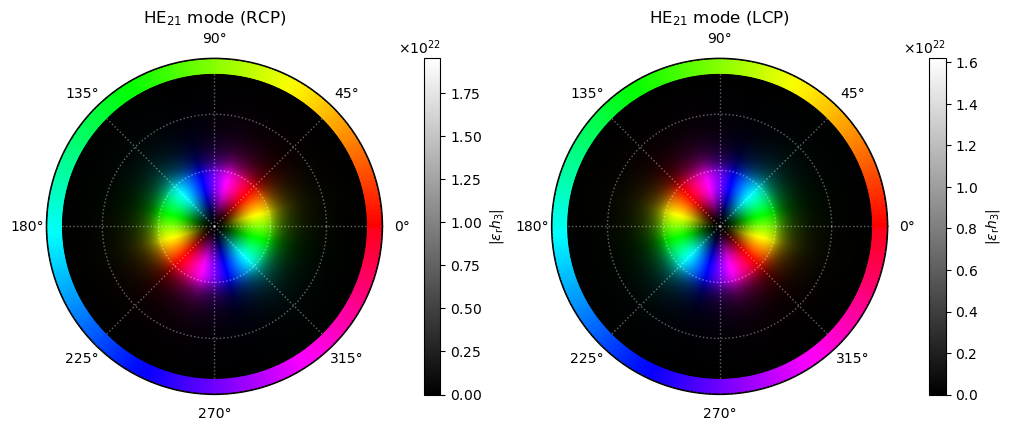

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [9]:
# Electric fields
E4 = HE21_wl3_R.E(rho=Rho, phi=Phi, z=0)
E5 = HE21_wl3_L.E(rho=Rho, phi=Phi, z=0)

# Reuse existing fields and grid; compute both overlaps once
cross01 = np.cross(E0, E1)
h3_R = np.sum(np.conjugate(E4) * cross01, axis=-1)
h3_L = np.sum(np.conjugate(E5) * cross01, axis=-1)

h3_R_masked = np.ma.masked_where(Rho.value < fibre.core_radius, h3_R)
h3_L_masked = np.ma.masked_where(Rho.value < fibre.core_radius, h3_L)
h3_R_eps = h3_R * fibre.eps(Rho, wl3)
h3_L_eps = h3_L * fibre.eps(Rho, wl3)
h3_R_masked_value = np.asarray(h3_R_masked.filled(0.0 + 0.0j), dtype=np.complex128)
h3_L_masked_value = np.asarray(h3_L_masked.filled(0.0 + 0.0j), dtype=np.complex128)

# Area element (reuse if available)
try:
    dS
except NameError:
    dphi = 2*np.pi/Nphi
    dr = rho.max()/(Nr-1)
    dS = Rho * dr * dphi

H3_R_ = np.sum(h3_R_masked_value * (u.V/u.m)**3 * dS)
H3_L_ = np.sum(h3_L_masked_value * (u.V/u.m)**3 * dS)

# Side-by-side plots
fig, axs = plt.subplots(1, 2, subplot_kw=dict(projection='polar'), figsize=(10, 5), constrained_layout=True)

kwargsR = {**kwargsP, 'title': r"$\mathrm{HE}_{21}$ mode (RCP)"}
kwargsL = {**kwargsP, 'title': r"$\mathrm{HE}_{21}$ mode (LCP)"}

plot_complex_field_polar(h3_R_eps, ax=axs[0], **kwargsR)
plot_complex_field_polar(h3_L_eps, ax=axs[1], **kwargsL)
plt.show()

display(Latex(r"$\iiint\limits_\text{clad}h^\mathrm{RCP}_{3}\,\mathrm{d}V"
              r" = " + H3_R_._repr_latex_()[1:-1] + r" L_\mathrm{eff}$"))
display(Latex(r"$\iiint\limits_\text{clad}h^\mathrm{LCP}_{3}\,\mathrm{d}V"
              r" = " + H3_L_._repr_latex_()[1:-1] + r" L_\mathrm{eff}$"))
